# LIIF Training on Strong Lensing Dataset

This notebook contains the provided cells, converted into Jupyter `.ipynb` format.

## Cell 1: Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm
import glob


## Cell 2: Configuration

In [2]:
# Configuration - FIXED
CONFIG = {
    'hr_path': '/home/jovyan/work/pinn/super_resoltuion/dataset/Dataset/HR',
    'lr_path': '/home/jovyan/work/pinn/super_resoltuion/dataset/Dataset/LR',
    'batch_size': 16,          # Reasonable batch size
    'epochs': 100,
    'lr': 1e-4,
    'test_split': 0.1,
    'device': 'cuda',
    'seed': 42,
    'sample_q': 2304,          # Query points per image
    'num_workers': 0,
}

print(f"Using device: {CONFIG['device']}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Query points per batch: {CONFIG['batch_size'] * CONFIG['sample_q']:,}")

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True


Using device: cuda
Batch size: 16
Query points per batch: 36,864


### GPU info & batch size tip (optional)

In [3]:
# Optional: inspect GPU and get a starting batch_size suggestion
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / (1024**3)
    name = props.name
    print(f"GPU: {name}")
    print(f"Total VRAM: {total_gb:.1f} GB")

    if "H200" in name.upper():
        print("Detected NVIDIA H200.")
        print("Good starting point (defaults): batch_size=32")
        print("If you enable mixed precision (AMP), try 64 or 128, then confirm with the auto-tuner below.")
    else:
        print("Start with batch_size=8 or 16, then confirm with the auto-tuner below.")
else:
    print("CUDA not available; using CPU. Keep batch_size small (e.g., 1–4).")


GPU: NVIDIA H200
Total VRAM: 139.7 GB
Detected NVIDIA H200.
Good starting point (defaults): batch_size=32
If you enable mixed precision (AMP), try 64 or 128, then confirm with the auto-tuner below.


## Cell 3: Dataset Class

In [4]:
class LensingDataset(Dataset):
    def __init__(self, hr_path, lr_path):
        self.hr_files = sorted(glob.glob(os.path.join(hr_path, '*.npy')))
        self.lr_files = sorted(glob.glob(os.path.join(lr_path, '*.npy')))
        
        # Match HR and LR files by name
        hr_names = {os.path.basename(f): f for f in self.hr_files}
        lr_names = {os.path.basename(f): f for f in self.lr_files}
        
        common_names = set(hr_names.keys()) & set(lr_names.keys())
        self.hr_files = [hr_names[n] for n in sorted(common_names)]
        self.lr_files = [lr_names[n] for n in sorted(common_names)]
        
        print(f"Found {len(self.hr_files)} matched HR-LR pairs")
        
    def __len__(self):
        return len(self.hr_files)
    
    def __getitem__(self, idx):
        hr = np.load(self.hr_files[idx]).astype(np.float32)
        lr = np.load(self.lr_files[idx]).astype(np.float32)
        
        # Ensure shape is (C, H, W)
        if hr.ndim == 2:
            hr = hr[np.newaxis, ...]
        if lr.ndim == 2:
            lr = lr[np.newaxis, ...]
            
        # Normalize to [0, 1]
        hr = (hr - hr.min()) / (hr.max() - hr.min() + 1e-8)
        lr = (lr - lr.min()) / (lr.max() - lr.min() + 1e-8)
        
        hr = torch.from_numpy(hr)
        lr = torch.from_numpy(lr)
        
        return lr, hr


## Cell 4: LIIF Wrapper Dataset

In [5]:
class LIIFDataset(Dataset):
    """Wrapper that creates coordinate-based samples for LIIF training"""
    def __init__(self, base_dataset, sample_q=2304):
        self.base_dataset = base_dataset
        self.sample_q = sample_q
        
    def __len__(self):
        return len(self.base_dataset)
    
    def make_coord(self, shape, flatten=True):
        """Make coordinates at grid centers"""
        h, w = shape
        coord_h = torch.linspace(-1 + 1/h, 1 - 1/h, h)
        coord_w = torch.linspace(-1 + 1/w, 1 - 1/w, w)
        coord = torch.stack(torch.meshgrid(coord_h, coord_w, indexing='ij'), dim=-1)
        if flatten:
            coord = coord.view(-1, 2)
        return coord
    
    def __getitem__(self, idx):
        lr, hr = self.base_dataset[idx]
        
        # Create HR coordinates
        h, w = hr.shape[-2:]
        coord = self.make_coord((h, w))
        
        # Cell size (for cell decoding)
        cell = torch.ones(coord.shape[0], 2)
        cell[:, 0] *= 2 / h
        cell[:, 1] *= 2 / w
        
        # Flatten HR for ground truth
        gt = hr.view(hr.shape[0], -1).permute(1, 0)  # (H*W, C)
        
        # Sample random query points during training
        if self.sample_q is not None and self.sample_q < coord.shape[0]:
            sample_idx = torch.randperm(coord.shape[0])[:self.sample_q]
            coord = coord[sample_idx]
            cell = cell[sample_idx]
            gt = gt[sample_idx]
        
        return {
            'inp': lr,
            'coord': coord,
            'cell': cell,
            'gt': gt
        }


### Optional: GPU-preloaded LIIF dataset (fastest, uses lots of VRAM)

In [6]:
class LIIFDatasetGPU(Dataset):
    """Pre-load everything to GPU for maximum speed.

    Warning: This can use a lot of VRAM. If you OOM here, use the normal LIIFDataset.
    """

    def __init__(self, base_dataset, sample_q=2304, device='cuda'):
        self.sample_q = sample_q
        self.device = device

        print("Pre-loading dataset to GPU...")
        self.data = []

        for i in tqdm(range(len(base_dataset))):
            lr, hr = base_dataset[i]

            # Move to GPU immediately
            lr = lr.to(device)
            hr = hr.to(device)

            h, w = hr.shape[-2:]

            # Create coordinates on GPU
            coord = self._make_coord_gpu((h, w), device)

            # Create cell on GPU
            cell = torch.ones(coord.shape[0], 2, device=device)
            cell[:, 0] *= 2 / h
            cell[:, 1] *= 2 / w

            # Flatten HR for ground truth
            gt = hr.view(hr.shape[0], -1).permute(1, 0)  # (H*W, C)

            self.data.append({
                'inp': lr,
                'coord': coord,
                'cell': cell,
                'gt': gt
            })

        print(f"Loaded {len(self.data)} samples to GPU")

        if torch.cuda.is_available():
            mem = torch.cuda.memory_allocated() / 1e9
            print(f"GPU memory used (allocated): {mem:.2f} GB")

    def _make_coord_gpu(self, shape, device):
        h, w = shape
        coord_h = torch.linspace(-1 + 1/h, 1 - 1/h, h, device=device)
        coord_w = torch.linspace(-1 + 1/w, 1 - 1/w, w, device=device)
        coord = torch.stack(torch.meshgrid(coord_h, coord_w, indexing='ij'), dim=-1)
        return coord.view(-1, 2)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data = self.data[idx]

        # Random sampling on GPU
        if self.sample_q is not None and self.sample_q < data['coord'].shape[0]:
            sample_idx = torch.randperm(data['coord'].shape[0], device=self.device)[:self.sample_q]
            return {
                'inp': data['inp'],
                'coord': data['coord'][sample_idx],
                'cell': data['cell'][sample_idx],
                'gt': data['gt'][sample_idx]
            }

        return data


def gpu_collate(batch):
    """Collate function for data already on GPU"""
    return {
        'inp': torch.stack([b['inp'] for b in batch]),
        'coord': torch.stack([b['coord'] for b in batch]),
        'cell': torch.stack([b['cell'] for b in batch]),
        'gt': torch.stack([b['gt'] for b in batch])
    }


## Cell 5: EDSR Encoder

In [7]:
class ResBlock(nn.Module):
    def __init__(self, n_feats, kernel_size=3, res_scale=0.1):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_feats, n_feats, kernel_size, padding=kernel_size//2),
            nn.ReLU(True),
            nn.Conv2d(n_feats, n_feats, kernel_size, padding=kernel_size//2),
        )
        self.res_scale = res_scale

    def forward(self, x):
        return x + self.body(x) * self.res_scale


class EDSR(nn.Module):
    def __init__(self, n_colors=1, n_feats=64, n_resblocks=16, kernel_size=3, res_scale=0.1):
        super().__init__()
        
        # Head
        self.head = nn.Conv2d(n_colors, n_feats, kernel_size, padding=kernel_size//2)
        
        # Body
        body = [ResBlock(n_feats, kernel_size, res_scale) for _ in range(n_resblocks)]
        body.append(nn.Conv2d(n_feats, n_feats, kernel_size, padding=kernel_size//2))
        self.body = nn.Sequential(*body)
        
        self.out_dim = n_feats

    def forward(self, x):
        x = self.head(x)
        res = self.body(x)
        return x + res


## Cell 6: MLP Decoder

In [8]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_list):
        super().__init__()
        layers = []
        lastv = in_dim
        for hidden in hidden_list:
            layers.append(nn.Linear(lastv, hidden))
            layers.append(nn.ReLU())
            lastv = hidden
        layers.append(nn.Linear(lastv, out_dim))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


## Cell 7: LIIF Model

In [9]:
class LIIF(nn.Module):
    def __init__(self, n_colors=1, encoder_dim=64, hidden_list=[256, 256, 256, 256],
                 local_ensemble=True, feat_unfold=True, cell_decode=True):
        super().__init__()
        
        self.local_ensemble = local_ensemble
        self.feat_unfold = feat_unfold
        self.cell_decode = cell_decode
        
        # Encoder
        self.encoder = EDSR(n_colors=n_colors, n_feats=encoder_dim)
        
        # Calculate input dimension for MLP
        imnet_in_dim = encoder_dim
        if self.feat_unfold:
            imnet_in_dim *= 9
        imnet_in_dim += 2  # coord
        if self.cell_decode:
            imnet_in_dim += 2  # cell
            
        # Implicit function (MLP)
        self.imnet = MLP(imnet_in_dim, n_colors, hidden_list)
        
    def query_rgb(self, feat, coord, cell=None):
        """Query RGB values at coordinates"""
        
        if self.feat_unfold:
            feat = F.unfold(feat, 3, padding=1).view(
                feat.shape[0], feat.shape[1] * 9, feat.shape[2], feat.shape[3])

        if self.local_ensemble:
            vx_lst = [-1, 1]
            vy_lst = [-1, 1]
            eps_shift = 1e-6
        else:
            vx_lst, vy_lst, eps_shift = [0], [0], 0

        # Field radius
        rx = 2 / feat.shape[-2] / 2
        ry = 2 / feat.shape[-1] / 2

        feat_coord = self.make_coord(feat.shape[-2:], flatten=False).to(feat.device)
        feat_coord = feat_coord.permute(2, 0, 1).unsqueeze(0).expand(feat.shape[0], 2, *feat.shape[-2:])

        preds = []
        areas = []
        
        for vx in vx_lst:
            for vy in vy_lst:
                coord_ = coord.clone()
                coord_[:, :, 0] += vx * rx + eps_shift
                coord_[:, :, 1] += vy * ry + eps_shift
                coord_.clamp_(-1 + 1e-6, 1 - 1e-6)

                q_feat = F.grid_sample(
                    feat, coord_.flip(-1).unsqueeze(1),
                    mode='nearest', align_corners=False)[:, :, 0, :].permute(0, 2, 1)

                q_coord = F.grid_sample(
                    feat_coord, coord_.flip(-1).unsqueeze(1),
                    mode='nearest', align_corners=False)[:, :, 0, :].permute(0, 2, 1)
                
                rel_coord = coord - q_coord
                rel_coord[:, :, 0] *= feat.shape[-2]
                rel_coord[:, :, 1] *= feat.shape[-1]
                
                inp = torch.cat([q_feat, rel_coord], dim=-1)

                if self.cell_decode:
                    rel_cell = cell.clone()
                    rel_cell[:, :, 0] *= feat.shape[-2]
                    rel_cell[:, :, 1] *= feat.shape[-1]
                    inp = torch.cat([inp, rel_cell], dim=-1)

                bs, q = coord.shape[:2]
                pred = self.imnet(inp.view(bs * q, -1)).view(bs, q, -1)
                preds.append(pred)

                area = torch.abs(rel_coord[:, :, 0] * rel_coord[:, :, 1])
                areas.append(area + 1e-9)

        tot_area = torch.stack(areas).sum(dim=0)
        
        if self.local_ensemble:
            t = areas[0]; areas[0] = areas[3]; areas[3] = t
            t = areas[1]; areas[1] = areas[2]; areas[2] = t
        
        ret = 0
        for pred, area in zip(preds, areas):
            ret = ret + pred * (area / tot_area).unsqueeze(-1)
        return ret
    
    def make_coord(self, shape, flatten=True):
        h, w = shape
        coord_h = torch.linspace(-1 + 1/h, 1 - 1/h, h)
        coord_w = torch.linspace(-1 + 1/w, 1 - 1/w, w)
        coord = torch.stack(torch.meshgrid(coord_h, coord_w, indexing='ij'), dim=-1)
        if flatten:
            coord = coord.view(-1, 2)
        return coord

    def forward(self, inp, coord, cell):
        feat = self.encoder(inp)
        return self.query_rgb(feat, coord, cell)


## Cell 8: Metrics Functions

In [10]:
def calculate_mse(pred, gt):
    """Calculate Mean Squared Error"""
    return F.mse_loss(pred, gt).item()

def calculate_psnr(pred, gt):
    """Calculate Peak Signal-to-Noise Ratio"""
    pred_np = pred.detach().cpu().numpy()
    gt_np = gt.detach().cpu().numpy()
    
    psnr_values = []
    for p, g in zip(pred_np, gt_np):
        psnr_values.append(psnr(g, p, data_range=1.0))
    return np.mean(psnr_values)

def calculate_ssim(pred, gt):
    """Calculate Structural Similarity Index"""
    pred_np = pred.detach().cpu().numpy()
    gt_np = gt.detach().cpu().numpy()
    
    ssim_values = []
    for p, g in zip(pred_np, gt_np):
        # Handle single channel
        if p.ndim == 3 and p.shape[0] == 1:
            p = p[0]
            g = g[0]
        ssim_values.append(ssim(g, p, data_range=1.0))
    return np.mean(ssim_values)


## Cell 9: Training Function

In [11]:
# AMP utilities (PyTorch 2.0+). Fallback for older versions.
try:
    from torch.amp import autocast, GradScaler
except Exception:
    from torch.cuda.amp import autocast, GradScaler


def train_epoch_fast(model, dataloader, optimizer, device, scaler):
    """Optimized training"""
    model.train()
    total_loss = 0

    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        # Move to GPU
        inp = batch['inp'].cuda(non_blocking=True)
        coord = batch['coord'].cuda(non_blocking=True)
        cell = batch['cell'].cuda(non_blocking=True)
        gt = batch['gt'].cuda(non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass
        try:
            # torch.amp autocast signature
            ctx = autocast('cuda', dtype=torch.float16)
        except TypeError:
            # torch.cuda.amp autocast signature
            ctx = autocast(dtype=torch.float16)

        with ctx:
            pred = model(inp, coord, cell)
            loss = F.l1_loss(pred, gt)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(dataloader)

def train_epoch_gpu(model, dataloader, optimizer, scaler):
    """Ultra-fast training: data already on GPU"""
    model.train()
    total_loss = 0

    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        inp = batch['inp']
        coord = batch['coord']
        cell = batch['cell']
        gt = batch['gt']

        optimizer.zero_grad(set_to_none=True)

        try:
            # torch.amp autocast signature
            ctx = autocast('cuda', dtype=torch.float16)
        except TypeError:
            # torch.cuda.amp autocast signature
            ctx = autocast(dtype=torch.float16)

        with ctx:
            pred = model(inp, coord, cell)
            loss = F.l1_loss(pred, gt)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(dataloader)


## Cell 10: Validation Function

In [12]:
@torch.no_grad()
def validate(model, dataloader, device):
    model.eval()
    total_mse = 0
    total_psnr = 0
    total_ssim = 0
    count = 0
    
    for batch in tqdm(dataloader, desc='Validating'):
        inp = batch['inp'].to(device)
        coord = batch['coord'].to(device)
        cell = batch['cell'].to(device)
        gt = batch['gt'].to(device)
        
        pred = model(inp, coord, cell)
        
        # Reshape for metrics (B, C, H, W)
        bs = inp.shape[0]
        h = w = int(np.sqrt(gt.shape[1]))
        pred_img = pred.permute(0, 2, 1).view(bs, -1, h, w)
        gt_img = gt.permute(0, 2, 1).view(bs, -1, h, w)
        
        total_mse += calculate_mse(pred_img, gt_img)
        total_psnr += calculate_psnr(pred_img, gt_img)
        total_ssim += calculate_ssim(pred_img, gt_img)
        count += 1
    
    return {
        'mse': total_mse / count,
        'psnr': total_psnr / count,
        'ssim': total_ssim / count
    }


## Cell 11: Super-resolve Full Image

In [13]:
@torch.no_grad()
def super_resolve(model, lr_img, hr_shape, device):
    """Super-resolve a single LR image to HR shape"""
    model.eval()
    
    if lr_img.dim() == 3:
        lr_img = lr_img.unsqueeze(0)
    lr_img = lr_img.to(device)
    
    h, w = hr_shape
    
    # Create coordinates for full HR image
    coord_h = torch.linspace(-1 + 1/h, 1 - 1/h, h)
    coord_w = torch.linspace(-1 + 1/w, 1 - 1/w, w)
    coord = torch.stack(torch.meshgrid(coord_h, coord_w, indexing='ij'), dim=-1)
    coord = coord.view(1, -1, 2).to(device)
    
    # Cell size
    cell = torch.ones(1, coord.shape[1], 2).to(device)
    cell[:, :, 0] *= 2 / h
    cell[:, :, 1] *= 2 / w
    
    # Predict
    pred = model(lr_img, coord, cell)
    pred = pred.view(1, h, w, -1).permute(0, 3, 1, 2)
    
    return pred.squeeze(0).cpu()


## Cell 12: Visualization Functions

In [14]:
def plot_samples(dataset, num_samples=4):
    """Plot sample LR-HR pairs from dataset"""
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, 4*num_samples))
    
    for i in range(num_samples):
        lr, hr = dataset.base_dataset[i]
        
        axes[i, 0].imshow(lr.squeeze(), cmap='viridis')
        axes[i, 0].set_title(f'LR Image {i+1} - Shape: {lr.shape}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(hr.squeeze(), cmap='viridis')
        axes[i, 1].set_title(f'HR Image {i+1} - Shape: {hr.shape}')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('L1 Loss')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # MSE
    axes[0, 1].plot(history['val_mse'], label='Val MSE', color='orange')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('MSE')
    axes[0, 1].set_title('Validation MSE')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # PSNR
    axes[1, 0].plot(history['val_psnr'], label='Val PSNR', color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('PSNR (dB)')
    axes[1, 0].set_title('Validation PSNR')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # SSIM
    axes[1, 1].plot(history['val_ssim'], label='Val SSIM', color='red')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('SSIM')
    axes[1, 1].set_title('Validation SSIM')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()


def plot_results(model, test_dataset, device, num_samples=4):
    """Plot LR, SR, HR comparison"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    
    for i in range(num_samples):
        lr, hr = test_dataset.base_dataset[i]
        hr_shape = hr.shape[-2:]
        
        sr = super_resolve(model, lr, hr_shape, device)
        
        axes[i, 0].imshow(lr.squeeze(), cmap='viridis')
        axes[i, 0].set_title(f'LR Input\n{lr.shape}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(sr.squeeze(), cmap='viridis')
        axes[i, 1].set_title(f'Super-Resolved\n{sr.shape}')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(hr.squeeze(), cmap='viridis')
        axes[i, 2].set_title(f'HR Ground Truth\n{hr.shape}')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()


## Cell 13: Create Dataset and DataLoaders

In [15]:
# Create base dataset
base_dataset = LensingDataset(CONFIG['hr_path'], CONFIG['lr_path'])

# Split into train and test
test_size = int(len(base_dataset) * CONFIG['test_split'])
train_size = len(base_dataset) - test_size

train_base, test_base = random_split(
    base_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(CONFIG['seed'])
)

print(f"Train samples: {len(train_base)}")
print(f"Test samples: {len(test_base)}")

# Wrap with LIIF dataset
train_dataset = LIIFDataset(train_base, sample_q=CONFIG['sample_q'])
test_dataset = LIIFDataset(test_base, sample_q=None)

# Recreate dataloaders with fixed batch size
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],  # Should be 16, not 256
    shuffle=True,
    num_workers=CONFIG['num_workers']
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Batch size: {CONFIG['batch_size']}")

# Verify
batch = next(iter(train_loader))
print(f"Actual batch shape: {batch['inp'].shape}")


Found 10000 matched HR-LR pairs
Train samples: 9000
Test samples: 1000
Train batches per epoch: 563
Batch size: 16
Actual batch shape: torch.Size([16, 1, 75, 75])


### Optional: GPU DataLoaders (no CPU→GPU transfer)

In [16]:
# Create GPU-accelerated datasets (optional)
# If this OOMs, skip this cell and use `train_loader` / `test_loader` instead.

print("Creating GPU-accelerated datasets...")

train_dataset_gpu = None
test_dataset_gpu = None
train_loader_gpu = None
test_loader_gpu = None

try:
    train_dataset_gpu = LIIFDatasetGPU(train_base, sample_q=CONFIG['sample_q'], device='cuda')
    test_dataset_gpu = LIIFDatasetGPU(test_base, sample_q=None, device='cuda')

    train_loader_gpu = DataLoader(
        train_dataset_gpu,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=0,
        collate_fn=gpu_collate
    )

    test_loader_gpu = DataLoader(
        test_dataset_gpu,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=gpu_collate
    )

    print(f"Train batches (GPU): {len(train_loader_gpu)}")
except RuntimeError as e:
    if 'out of memory' in str(e).lower():
        print("OOM while preloading dataset to GPU. Use the normal CPU dataset+loader.")
        torch.cuda.empty_cache()
    else:
        raise


Creating GPU-accelerated datasets...
Pre-loading dataset to GPU...


100%|██████████| 9000/9000 [05:22<00:00, 27.92it/s]


Loaded 9000 samples to GPU
GPU memory used (allocated): 4.26 GB
Pre-loading dataset to GPU...


100%|██████████| 1000/1000 [00:33<00:00, 29.67it/s]

Loaded 1000 samples to GPU
GPU memory used (allocated): 4.73 GB
Train batches (GPU): 563


### Quick test (after fixing batch size)

In [18]:
# Verify the fix (run after Cell 15 so `model`/`optimizer` exist)
missing = [k for k in ['model', 'optimizer', 'train_loader'] if k not in globals()]
if missing:
    print(f"Missing {missing}. Run Cell 15 (Initialize Model) first, then re-run this cell.")
else:
    if not torch.cuda.is_available():
        raise RuntimeError('CUDA is not available, but this timing test expects a GPU.')

    print(f"Batch size in config: {CONFIG['batch_size']}")

    batch = next(iter(train_loader))
    print(f"Actual batch inp shape: {batch['inp'].shape}")
    print(f"Actual batch coord shape: {batch['coord'].shape}")
    print(f"Total query points: {batch['inp'].shape[0] * batch['coord'].shape[1]:,}")

    # Time one training step
    import time
    model.train()

    try:
        from torch.amp import autocast, GradScaler
    except Exception:
        from torch.cuda.amp import autocast, GradScaler

    scaler = GradScaler()

    inp = batch['inp'].cuda(non_blocking=True)
    coord = batch['coord'].cuda(non_blocking=True)
    cell = batch['cell'].cuda(non_blocking=True)
    gt = batch['gt'].cuda(non_blocking=True)

    torch.cuda.synchronize()
    start = time.time()

    optimizer.zero_grad(set_to_none=True)

    try:
        ctx = autocast('cuda')
    except TypeError:
        ctx = autocast()

    with ctx:
        pred = model(inp, coord, cell)
        loss = F.l1_loss(pred, gt)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    torch.cuda.synchronize()
    elapsed = time.time() - start

    print(f"Time for 1 training step: {elapsed*1000:.0f}ms")
    print(f"Expected epoch time: {elapsed * len(train_loader):.1f}s")


Missing ['model', 'optimizer']. Run Cell 15 (Initialize Model) first, then re-run this cell.


## Cell 14: Visualize Dataset

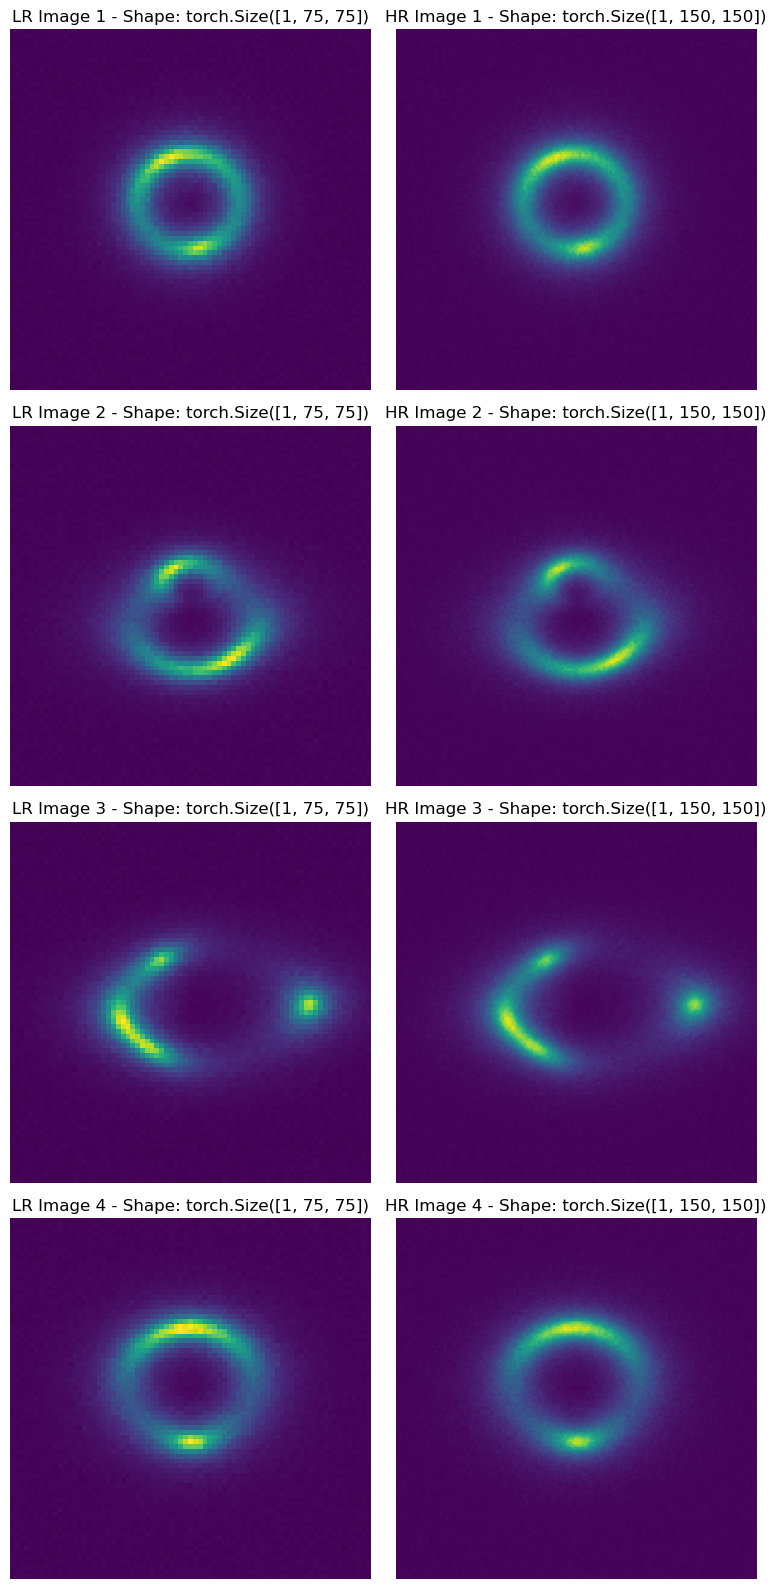

In [19]:
# Plot some samples
plot_samples(train_dataset, num_samples=4)


## Cell 15: Initialize Model

In [20]:
# Initialize model (NO torch.compile)
model = LIIF(
    n_colors=1,
    encoder_dim=64,
    hidden_list=[256, 256, 256, 256],
    local_ensemble=True,
    feat_unfold=True,
    cell_decode=True
).to(CONFIG['device'])

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Optimizer with fused AdamW (faster on GPU)
try:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['lr'],
        fused=True
    )
    print("Using fused AdamW optimizer")
except Exception:
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
    print("Using standard Adam optimizer")

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['epochs'],
    eta_min=1e-6
)


Total parameters: 1,565,633
Using fused AdamW optimizer


### Auto-tune batch size (optional)

In [22]:
# Optional: estimate a safe batch_size WITHOUT changing CONFIG.
# Run this only if you want a suggestion.

def _try_one_step(batch_size):
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    batch = next(iter(loader))

    inp = batch['inp'].cuda()
    coord = batch['coord'].cuda()
    cell = batch['cell'].cuda()
    gt = batch['gt'].cuda()

    model.train()
    opt = torch.optim.SGD(model.parameters(), lr=0.0)
    opt.zero_grad(set_to_none=True)

    torch.cuda.reset_peak_memory_stats()

    pred = model(inp, coord, cell)
    loss = F.l1_loss(pred, gt)
    loss.backward()

    peak_gb = torch.cuda.max_memory_allocated() / (1024**3)

    del inp, coord, cell, gt, pred, loss
    torch.cuda.empty_cache()

    return peak_gb


def find_max_batch_size(candidates=(4, 8, 16, 32, 64, 128)):
    ok = None
    for bs in candidates:
        try:
            peak = _try_one_step(bs)
            ok = bs
            print(f"batch_size={bs:>4} OK (peak allocated ~{peak:.2f} GB)")
        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                print(f"batch_size={bs:>4} OOM")
                torch.cuda.empty_cache()
                break
            raise
    return ok


suggested = find_max_batch_size()
print(f"Suggested batch_size (manual): {suggested}")
print(f"Current CONFIG['batch_size']: {CONFIG['batch_size']}")


batch_size=   4 OK (peak allocated ~5.25 GB)
batch_size=   8 OK (peak allocated ~5.51 GB)
batch_size=  16 OK (peak allocated ~6.40 GB)
batch_size=  32 OK (peak allocated ~8.32 GB)
batch_size=  64 OK (peak allocated ~12.17 GB)
batch_size= 128 OK (peak allocated ~19.86 GB)
Suggested batch_size (manual): 128
Current CONFIG['batch_size']: 16


## Cell 16: Training Loop

In [25]:
# Initialize gradient scaler for AMP
try:
    from torch.amp import GradScaler
except Exception:
    from torch.cuda.amp import GradScaler

scaler = GradScaler()

# Training history
history = {
    'train_loss': [],
    'val_mse': [],
    'val_psnr': [],
    'val_ssim': []
}

best_psnr = 0
best_model_state = None

print("Starting training with Mixed Precision (AMP)...")
print(f"Batch size: {CONFIG['batch_size']}, Workers: {CONFIG['num_workers']}")
print("="*60)

# Use GPU-preloaded loaders if they exist
train_loader_used = train_loader_gpu if 'train_loader_gpu' in globals() and train_loader_gpu is not None else train_loader
test_loader_used = test_loader_gpu if 'test_loader_gpu' in globals() and test_loader_gpu is not None else test_loader
if 'train_epoch_gpu' in globals() and (train_loader_used is train_loader_gpu):
    train_step_fn = lambda m, dl, opt, dev, sc: train_epoch_gpu(m, dl, opt, sc)
else:
    train_step_fn = train_epoch_fast


import time
start_time = time.time()

for epoch in range(1, CONFIG['epochs'] + 1):
    epoch_start = time.time()

    # Train with AMP
    train_loss = train_step_fn(model, train_loader_used, optimizer, CONFIG['device'], scaler)
    history['train_loss'].append(train_loss)

    epoch_time = time.time() - epoch_start

    # Validate every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        metrics = validate(model, test_loader_used, CONFIG['device'])
        history['val_mse'].append(metrics['mse'])
        history['val_psnr'].append(metrics['psnr'])
        history['val_ssim'].append(metrics['ssim'])

        print(f"Epoch {epoch}/{CONFIG['epochs']} ({epoch_time:.1f}s)")
        print(f"  Loss: {train_loss:.6f} | MSE: {metrics['mse']:.6f} | PSNR: {metrics['psnr']:.2f} dB | SSIM: {metrics['ssim']:.4f}")

        if metrics['psnr'] > best_psnr:
            best_psnr = metrics['psnr']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ★ New best! PSNR: {best_psnr:.2f} dB")
    else:
        print(f"Epoch {epoch}/{CONFIG['epochs']} - Loss: {train_loss:.6f} ({epoch_time:.1f}s)")

    scheduler.step()

total_time = time.time() - start_time
print(" " + "="*60)
print(f"Training complete in {total_time/60:.1f} minutes")
print(f"Best PSNR: {best_psnr:.2f} dB")


Starting training with Mixed Precision (AMP)...
Batch size: 16, Workers: 0


Validating: 100%|██████████| 1000/1000 [00:05<00:00, 199.38it/s]


Epoch 1/100 (72.4s)
  Loss: 0.008043 | MSE: 0.000104 | PSNR: 40.01 dB | SSIM: 0.9663
  ★ New best! PSNR: 40.01 dB


Training: 100%|██████████| 563/563 [00:13<00:00, 42.20it/s, loss=0.0057]


Epoch 2/100 - Loss: 0.005776 (13.3s)


...

Epoch 98/100 - Loss: 0.005099 (13.1s)


Training: 100%|██████████| 563/563 [00:13<00:00, 42.85it/s, loss=0.0053]


Epoch 99/100 - Loss: 0.005099 (13.1s)


Validating: 100%|██████████| 1000/1000 [00:05<00:00, 198.43it/s]


Epoch 100/100 (13.1s)
  Loss: 0.005098 | MSE: 0.000068 | PSNR: 41.79 dB | SSIM: 0.9766
  ★ New best! PSNR: 41.79 dB
Training complete in 27.5 minutes
Best PSNR: 41.79 dB


## Cell 17: Plot Training History

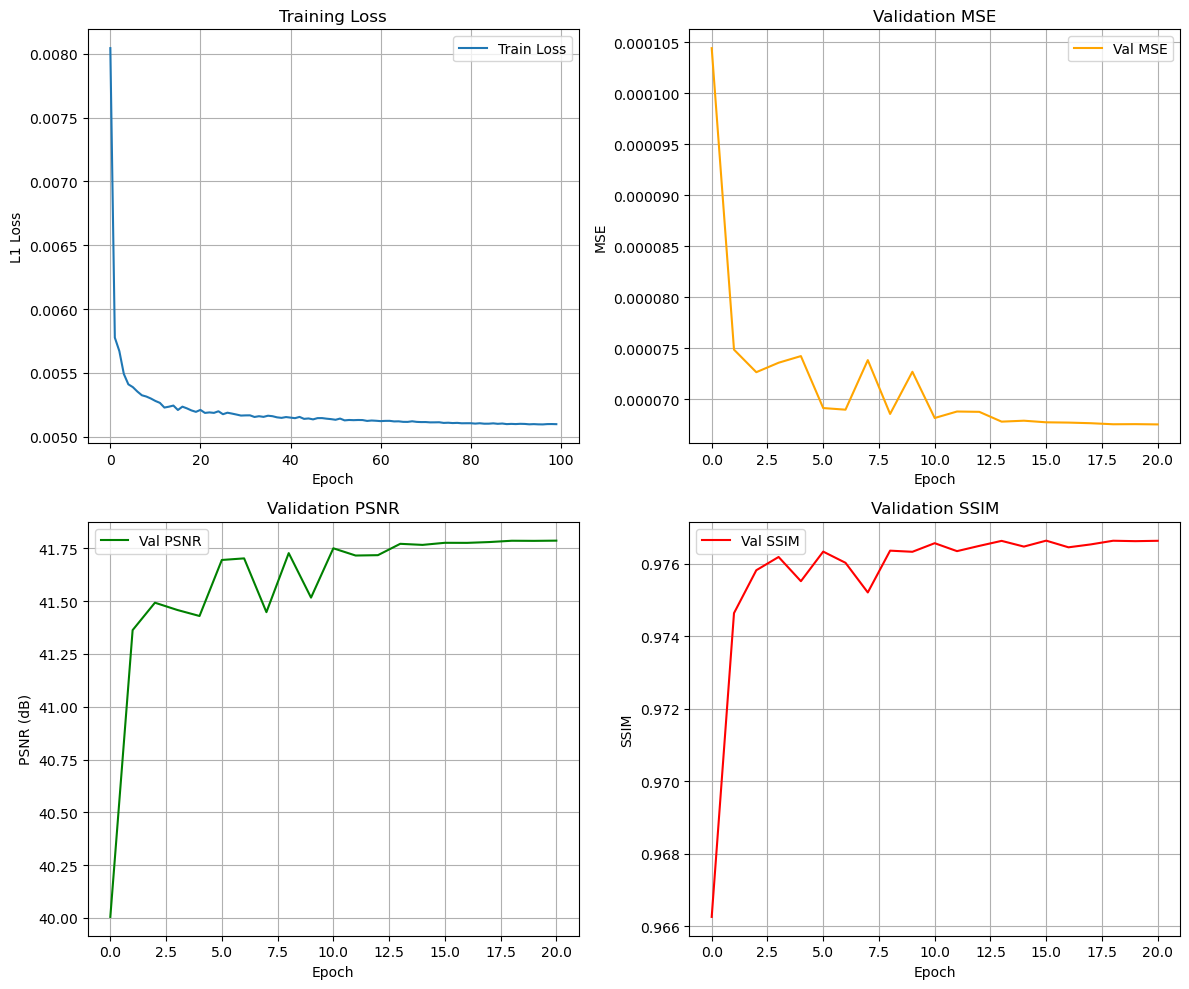

In [26]:
plot_training_history(history)


## Cell 18: Load Best Model and Final Evaluation

In [28]:
# Load best model
model.load_state_dict(best_model_state)

# Final evaluation
print("="*60)
print("           FINAL EVALUATION ON TEST SET")
print("="*60)

final_metrics = validate(model, test_loader, CONFIG['device'])

print(f"{'Metric':<30} {'Value':<20}")
print("-"*50)
print(f"{'MSE (Mean Squared Error)':<30} {final_metrics['mse']:.6f}")
print(f"{'PSNR (Peak Signal-to-Noise)':<30} {final_metrics['psnr']:.2f} dB")
print(f"{'SSIM (Structural Similarity)':<30} {final_metrics['ssim']:.4f}")
print("-"*50)


           FINAL EVALUATION ON TEST SET


Validating: 100%|██████████| 1000/1000 [01:37<00:00, 10.25it/s]

Metric                         Value               
--------------------------------------------------
MSE (Mean Squared Error)       0.000068
PSNR (Peak Signal-to-Noise)    41.79 dB
SSIM (Structural Similarity)   0.9766
--------------------------------------------------


### Detailed per-image metrics (optional)

In [30]:
@torch.no_grad()
def evaluate_per_image(model, test_dataset, device):
    # Calculate metrics for each test image individually
    model.eval()

    results = []

    for i in range(len(test_dataset.base_dataset)):
        lr, hr = test_dataset.base_dataset[i]
        hr_shape = hr.shape[-2:]

        # Super-resolve
        sr = super_resolve(model, lr, hr_shape, device)

        # Calculate metrics
        sr_np = sr.numpy()
        hr_np = hr.numpy()

        if sr_np.ndim == 3 and sr_np.shape[0] == 1:
            sr_np = sr_np[0]
            hr_np = hr_np[0]

        mse_val = float(np.mean((sr_np - hr_np) ** 2))
        psnr_val = float(psnr(hr_np, sr_np, data_range=1.0))
        ssim_val = float(ssim(hr_np, sr_np, data_range=1.0))

        results.append({
            'image_idx': i,
            'mse': mse_val,
            'psnr': psnr_val,
            'ssim': ssim_val,
        })

    return results


print("="*70)
print("                    PER-IMAGE EVALUATION METRICS")
print("="*70)

per_image_results = evaluate_per_image(model, test_dataset, CONFIG['device'])

print(f"{'Image':<10} {'MSE':<15} {'PSNR (dB)':<15} {'SSIM':<15}")
print("-"*55)

for r in per_image_results:
    print(f"{r['image_idx']:<10} {r['mse']:<15.6f} {r['psnr']:<15.2f} {r['ssim']:<15.4f}")

print("-"*55)

# Summary statistics
mse_values = [r['mse'] for r in per_image_results]
psnr_values = [r['psnr'] for r in per_image_results]
ssim_values = [r['ssim'] for r in per_image_results]

print("SUMMARY STATISTICS")
print("-"*55)
print(f"{'Metric':<15} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-"*55)
print(f"{'MSE':<15} {np.mean(mse_values):<12.6f} {np.std(mse_values):<12.6f} {np.min(mse_values):<12.6f} {np.max(mse_values):<12.6f}")
print(f"{'PSNR (dB)':<15} {np.mean(psnr_values):<12.2f} {np.std(psnr_values):<12.2f} {np.min(psnr_values):<12.2f} {np.max(psnr_values):<12.2f}")
print(f"{'SSIM':<15} {np.mean(ssim_values):<12.4f} {np.std(ssim_values):<12.4f} {np.min(ssim_values):<12.4f} {np.max(ssim_values):<12.4f}")
print("-"*55)


                    PER-IMAGE EVALUATION METRICS
Image      MSE             PSNR (dB)       SSIM           
-------------------------------------------------------
0          0.000083        40.79           0.9737         
1          0.000093        40.34           0.9729         
2          0.000086        40.65           0.9765         
3          0.000065        41.90           0.9747         
4          0.000066        41.83           0.9758         
5          0.000077        41.13           0.9747         
6          0.000054        42.70           0.9757         
7          0.000055        42.56           0.9791         
8          0.000085        40.70           0.9788         
9          0.000080        40.95           0.9785         
10         0.000056        42.54           0.9783         
11         0.000071        41.52           0.9813         
12         0.000054        42.66           0.9802         
13         0.000061        42.13           0.9767         
14        

### Metrics visualization (optional)

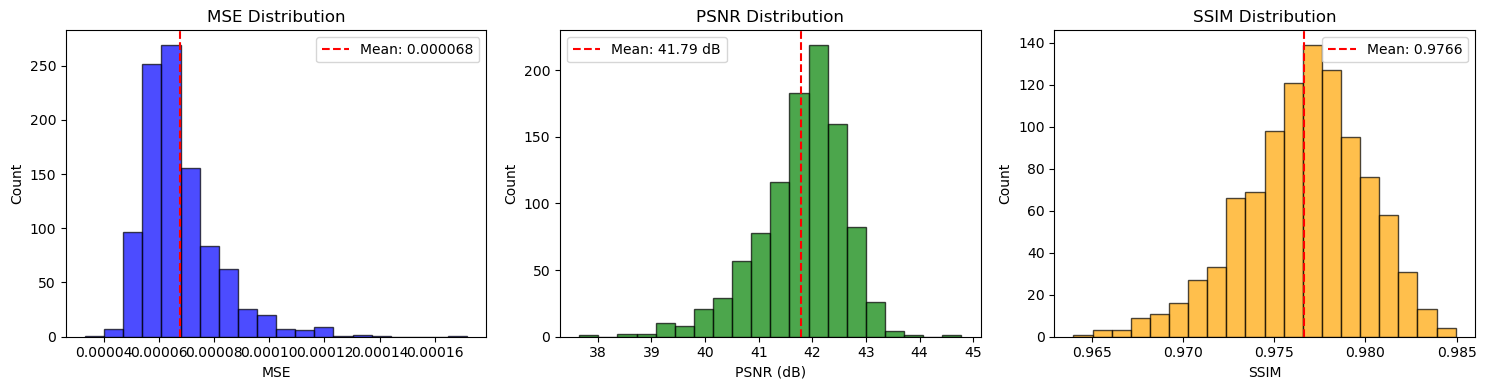

              FINAL METRICS SUMMARY
MSE  (Mean Squared Error):    0.000068
PSNR (Peak Signal-to-Noise):  41.79 dB
SSIM (Structural Similarity): 0.9766


In [31]:
# Visualize metrics distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MSE histogram
axes[0].hist(mse_values, bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(mse_values), color='red', linestyle='--', label=f"Mean: {np.mean(mse_values):.6f}")
axes[0].set_xlabel('MSE')
axes[0].set_ylabel('Count')
axes[0].set_title('MSE Distribution')
axes[0].legend()

# PSNR histogram
axes[1].hist(psnr_values, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(np.mean(psnr_values), color='red', linestyle='--', label=f"Mean: {np.mean(psnr_values):.2f} dB")
axes[1].set_xlabel('PSNR (dB)')
axes[1].set_ylabel('Count')
axes[1].set_title('PSNR Distribution')
axes[1].legend()

# SSIM histogram
axes[2].hist(ssim_values, bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[2].axvline(np.mean(ssim_values), color='red', linestyle='--', label=f"Mean: {np.mean(ssim_values):.4f}")
axes[2].set_xlabel('SSIM')
axes[2].set_ylabel('Count')
axes[2].set_title('SSIM Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

print(" " + "="*60)
print("              FINAL METRICS SUMMARY")
print("="*60)
print(f"MSE  (Mean Squared Error):    {np.mean(mse_values):.6f}")
print(f"PSNR (Peak Signal-to-Noise):  {np.mean(psnr_values):.2f} dB")
print(f"SSIM (Structural Similarity): {np.mean(ssim_values):.4f}")


## Cell 19: Visualize Results

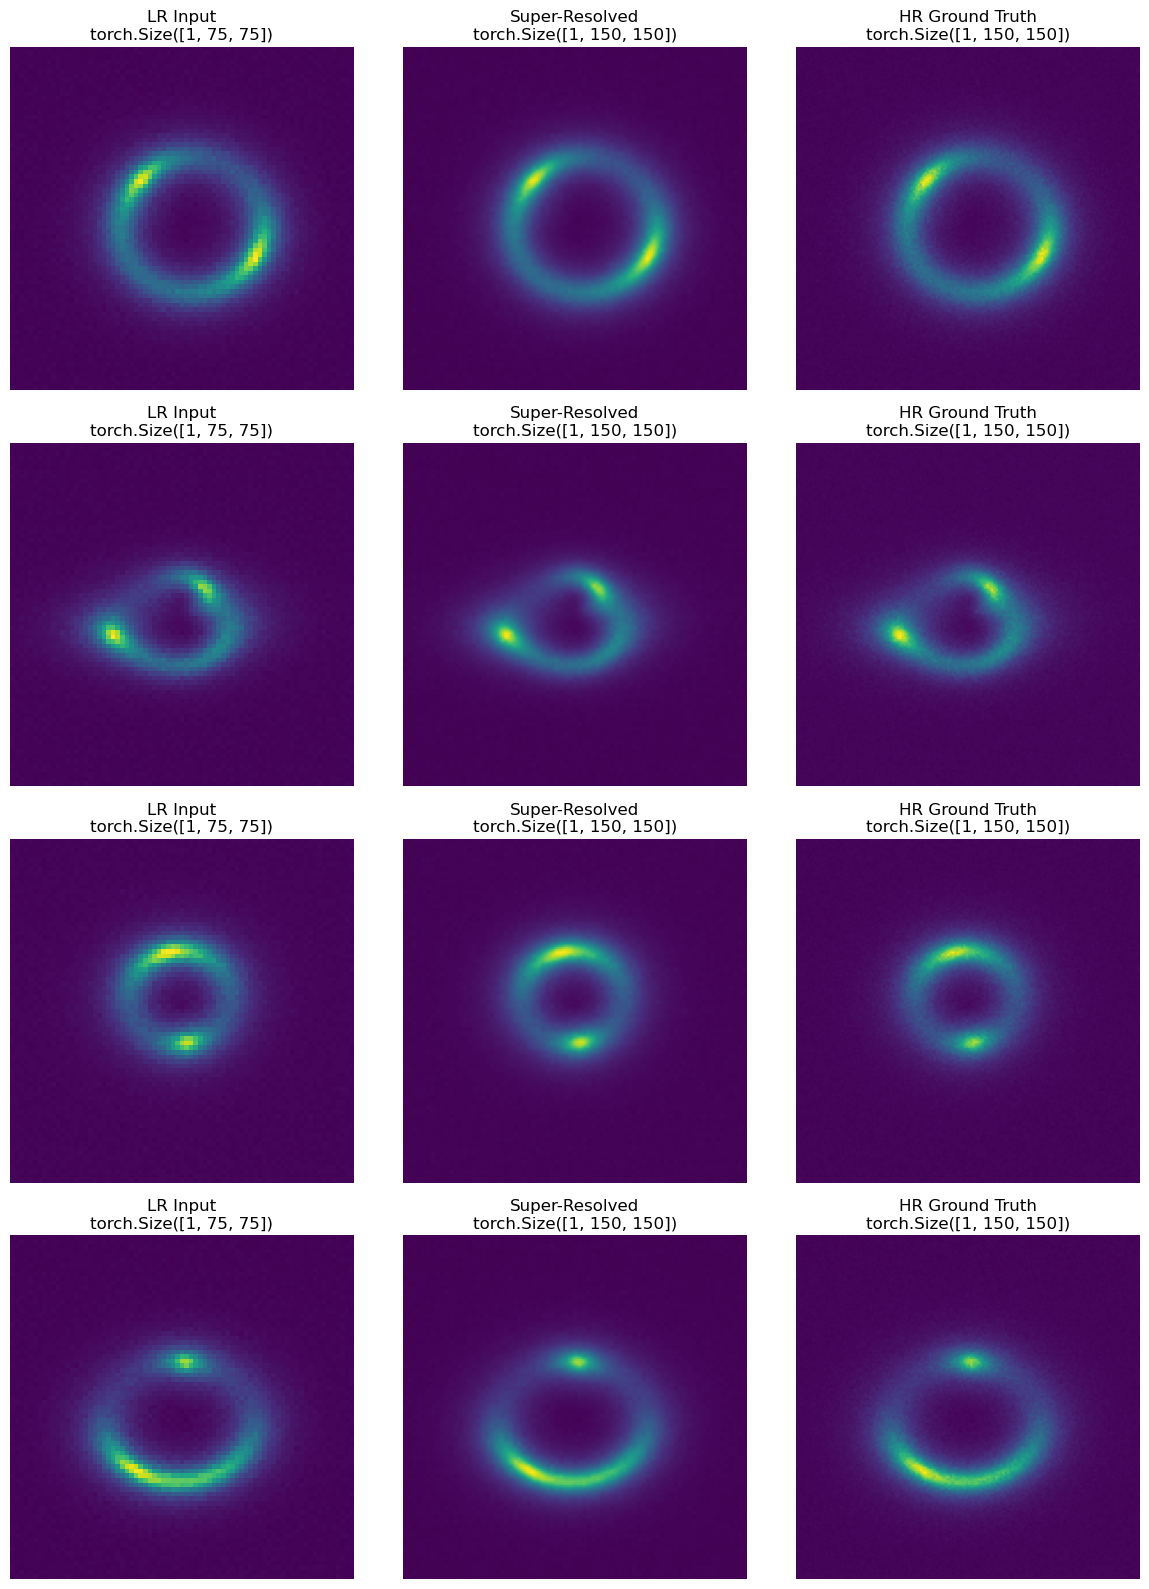

In [32]:
# Plot super-resolution results
plot_results(model, test_dataset, CONFIG['device'], num_samples=4)


## Cell 20: Save Model

In [33]:
# Save the trained model
save_path = 'liif_lensing_best.pth'
torch.save({
    'model_state_dict': best_model_state,
    'config': CONFIG,
    'final_metrics': final_metrics,
    'history': history
}, save_path)

print(f"Model saved to {save_path}")


Model saved to liif_lensing_best.pth


## Cell 21: Inference on Single Image

In [34]:
# Example: Super-resolve a single image
def inference_single(model, lr_path, hr_shape=(150, 150), device='cuda'):
    """Run inference on a single .npy file"""
    lr = np.load(lr_path).astype(np.float32)
    
    if lr.ndim == 2:
        lr = lr[np.newaxis, ...]
    
    lr = (lr - lr.min()) / (lr.max() - lr.min() + 1e-8)
    lr = torch.from_numpy(lr)
    
    sr = super_resolve(model, lr, hr_shape, device)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(lr.squeeze(), cmap='viridis')
    axes[0].set_title(f'LR Input: {lr.shape}')
    axes[0].axis('off')
    
    axes[1].imshow(sr.squeeze().numpy(), cmap='viridis')
    axes[1].set_title(f'Super-Resolved: {sr.shape}')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return sr

# Example usage (uncomment and modify path):
# sr_result = inference_single(model, '/path/to/your/lr_image.npy', hr_shape=(150, 150), device=CONFIG['device'])


## Notes

1. Update `CONFIG['hr_path']` and `CONFIG['lr_path']` to match your actual dataset paths.
2. The model expects grayscale images (1 channel) with shape `(1, H, W)`.
3. Adjust `batch_size` and `epochs` based on your GPU memory and training needs.
4. The `sample_q` parameter controls how many query points are sampled per image during training.